# Examen 1 - Métodos estadísticos Bayesianos

![](https://upload.wikimedia.org/wikipedia/commons/1/18/Bayes%27_Theorem_MMB_01.jpg)

Santiago Ayon Sanchez

## 1. Sobreventa en aerolíneas (60 puntos)

Supongamos que usted es la (el) encargad@ de la estrategia comercial de una aerolínea. Dado que las cancelaciones en los boletos y los pasajeros que no se presentan el día del vuelo es un asunto bastante recurrente, usted se plantea sobrevender los vuelos. La idea de la sobreventa es simple:

> Vendemos más boletos de los que en realidad tenemos capacidad, esperando que después de las cancelaciones, las personas que se presenten el día del vuelo coincidan con el número de asientos disponibles del avión.

Para simplificar un poco todo el problema, consideremos un vuelo arbitrario. Dada la naturaleza de este problema, se tiene gran incertidumbre en **cuantas personas se presentarán el día del vuelo**, por lo que usaremos un modelo probabilístico para modelar esta situación. Supongamos que:

- Nuestro avión tiene una capacidad $C$ de asientos.
- La demanda es lo suficientemente alta como para que todos los boletos que ponemos a la venta $B$ se vendan. En una estrategia de sobreventa, $B > C$.
- La probabilidad de que una persona arbitraria se presente al vuelo es $\theta$.
- El número de personas que se presentan al vuelo es $X$.

Con lo anterior, podemos modelar la variable aleatoria $X$ del número de personas que se presentan al vuelo como una distribución $\text{Binomial}(B, \theta)$. Es decir, la probabilidad de que se presenten $i$ personas al vuelo es:

$$
p(X = i) = \left(\begin{array}{c}B \\ i \end{array}\right) \theta^i (1 - \theta)^{B-i}.
$$

Con estas definiciones, podemos hablar también en términos de negocio. Por ejemplo, ¿cuál sería el costo de la sobreventa?

Simplificando nuevamente el problema, supongamos que la tarifa de cada boleto es $T$ y es la misma para todos los $B$ boletos. Supongamos que en el caso de que una persona se presente al vuelo, y no pueda abordar, le devolvemos su dinero (o equivalentemente lo abordamos en el siguiente vuelo disponible) más $k$ veces el costo del boleto, es decir $(k + 1) T$. Entonces, los costos por sobreventa son:

$$
c_{ob} = T (k + 1) \max(X - C, 0)
$$

Finalmente, los ingresos del vuelo descontando los costos por sobreventa son:

$$
I = T B - T (k + 1) \max(X - C, 0).
$$

### 1.1. (30 puntos) Máxima verosimilitud

1. (10 puntos) Supongamos que tenemos un avión con capacidad de $C=200$ pasajeros, y hacemos una sobreventa de $B=220$ boletos. Al vuelo se presentan $208$ personas. Bajo estas condiciones, ¿Cuál es el estimador de máxima verosimilitud para $\theta$?

Vamos a encontrar el estimador de máxima verosimilitud para $\theta$
$$
\mathcal{L}(\theta) = P(X = x) = \left(\begin{array}{c}B \\ x \end{array}\right) \theta^x (1 - \theta)^{B-x}
$$
Vamos a utilizar la Log-Verosimilitud
$$
\ell(\theta) = \ln \left[ \left(\begin{array}{c}B \\ x \end{array}\right) \right] + x \ln(\theta) + (B - x) \ln(1 - \theta)
$$

Maximizamos

$$
\frac{d}{d\theta} \ell(\theta) = \frac{x}{\theta} - \frac{B - x}{1 - \theta} = 0 \\
~ \\
\frac{x}{\theta} = \frac{B - x}{1 - \theta} \\ 
~ \\
x (1 - \theta) = \theta (B - x) \\ 
~ \\
x - x\theta = B\theta - x\theta \\
~ \\
x = B\theta
$$


$$\hat{\theta}_{MLE} = \frac{x}{B}$$

Encontrando entonces el estimador de maxima verosimilitud. Con los datos nos da lo siguiente 

$$
\hat{\theta}_{MLE} = \frac{208}{220} = 0.9454
$$

2. (10 puntos) Graficar la pmf $\text{Binomial}(B, \theta)$ con $B=220$ boletos y la $\theta$ estimada en el punto anterior.

In [20]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Definimos la distribucion binomial con B = 220 y theta = 0.9454
b = 220
theta = 0.9454
Binom = stats.binom(n=b, p=theta)

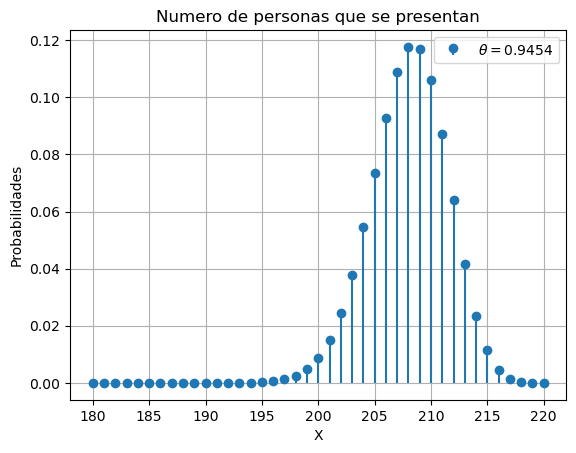

In [22]:
# Lo ponemos a partir de 180 porque todo lo demas es practicamente 0 y para que se 
# pueda visualizar de mejor manera
x = range(180, 221)
pk = Binom.pmf(x)

plt.stem(x, pk, basefmt=" ", label=r"$\theta = 0.9454$")
plt.xlabel('X')
plt.ylabel('Probabilidades')
plt.title('Numero de personas que se presentan')
plt.legend()
plt.grid()
plt.show()

3. (10 puntos) Considerando una tarifa $T=1000$, y que por cada pasajero que se presente y sea dejado fuera del vuelo devolvemos una vez la tarifa $k=1$, ¿Cuál sería el costo por sobreventa?, ¿Cuál sería el ingreso descontando dicho costo?, ¿En retrospectiva, habrías ofertado una sobreventa menor?

In [23]:
T = 1000
k = 1
X = 208
C = 200
B = 220

cob = T*(k+1) * max(X-C,0)
ingreso = T*B - cob

print(f"El costo por sobre venta es ${cob}")
print(f"El ingresos descontando el cosoto por sobre venta es ${ingreso}")

El costo por sobre venta es $16000
El ingresos descontando el cosoto por sobre venta es $204000


Viendolo en retrospectiva ya con la informacion que tenemos de la probabilidad de que alguien se presente $\theta$. Si hubiese ofertado una sobreventa menor ya que para nuestra $\theta$ de 0.9454 ofertar 20 era mucho. Lo ideal hubiese sido sobrevender 11 vuelos para que se vendieran 211 boletos y con la probabilidad que encontramos de 0.9454 se presentara justo las 200 personas y tener las ganancias mayores

### 1.2. (10 puntos) Selección de previas

Alejándonos un poco del punto anterior, queremos hacer una modelación Bayesiana. Para esto debemos seleccionar una distribución previa adecuada, dependiendo del conocimiento previo que tengamos acerca de la probabilidad de que una persona se presente en el vuelo $\theta$.

1. (15 puntos) Supongamos que, en principio, no tenemos información alguna sobre $\theta$.
   - ¿Qué previa modela esta situación?
   - Supongamos que tenemos un avión con capacidad de $C=200$ pasajeros, y hacemos una sobreventa de $B=220$ boletos. Al vuelo se presentan $207$ personas. Utilice una tabla de actualización Bayesiana para encontrar la distribución posterior de $\theta$.
   - Graficar la previa y la posterior.
   - Considerando una tarifa $T=1000$, y que por cada pasajero que se presente y sea dejado fuera del vuelo devolvemos una vez la tarifa $k=1$, ¿Cuál sería el costo por sobreventa?, ¿Cuál sería el ingreso descontando dicho costo?, ¿En retrospectiva, habrías ofertado una sobreventa menor?

1. La previa que utilizaria yo para modelar si no tengo información de la $\theta$ es una distribucion uniforme para no sesgar para nada $\theta$ porlo que que seria 1 en un rango de [0,1].

2. 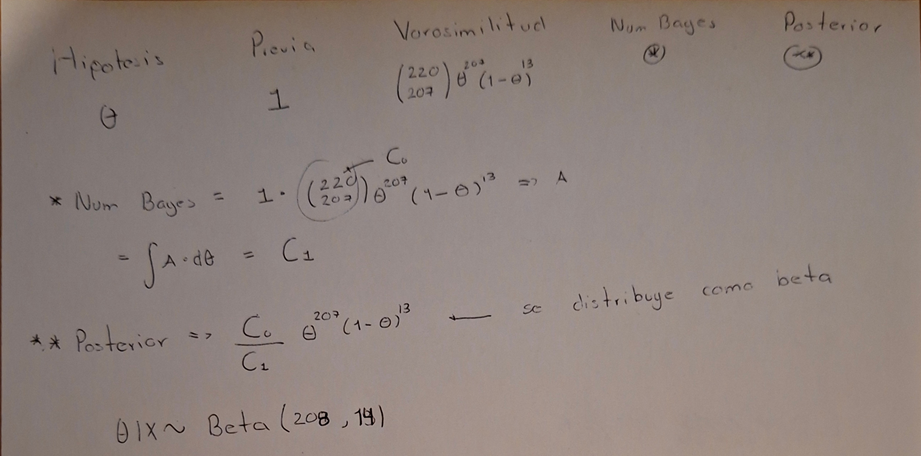

3.

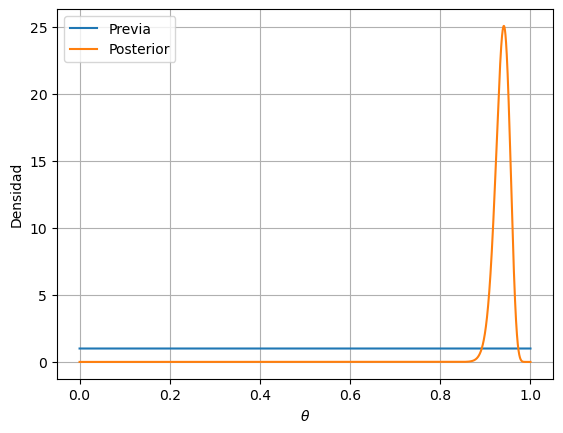

In [ ]:
theta = np.linspace(0, 1, 10000)

# Datos
B = 220
X = 207

# Previa
prior = stats.uniform.pdf(theta, 0, 1)
# Posterior
posterior = stats.beta.pdf(theta, X+1, B-X+1)

# Graficamos
plt.plot(theta, prior, label='Previa')
plt.plot(theta, posterior, label='Posterior')
plt.xlabel(r'$\theta$')
plt.ylabel('Densidad')
plt.legend()
plt.grid()
plt.show()

4.

In [25]:
T = 1000
k = 1
X = 207
C = 200
B = 220

cob = T*(k+1) * max(X-C,0)
ingreso = T*B - cob

print(f"El costo por sobre venta es ${cob}")
print(f"El ingresos descontando el cosoto por sobre venta es ${ingreso}")

El costo por sobre venta es $14000
El ingresos descontando el cosoto por sobre venta es $206000


Si hubiese ofertado una sobreventa menor ya que nuestro ingreso optimo puedo haber sido mayor. Al tener mucha asistencia nos arriesgamos al sobrevender tanto.

2. (15 puntos) Usando la posterior del punto anterior como previa, supongamos ahora que hacemos una sobreventa de $B=215$ boletos, y se presentan $198$ personas.
   - Utilice una tabla de actualización Bayesiana para encontrar la distribución posterior de $\theta$.
   - Graficar la previa y la posterior.
   - Considerando una tarifa $T=1000$, y que por cada pasajero que se presente y sea dejado fuera del vuelo devolvemos una vez la tarifa $k=1$, ¿Cuál sería el costo por sobreventa?, ¿Cuál sería el ingreso descontando dicho costo?, ¿En retrospectiva, habrías ofertado una sobreventa menor?

1. 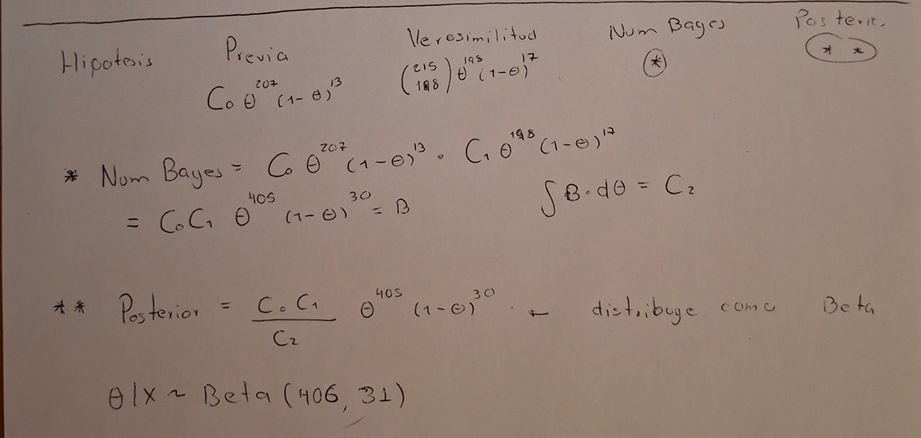

2.

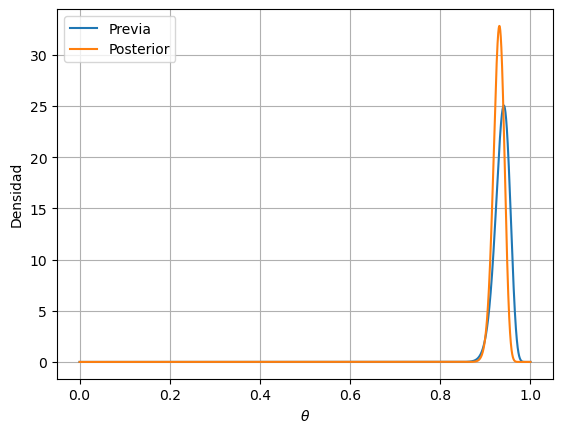

In [ ]:

theta = np.linspace(0, 1, 10000)

# Datos
B_p = 220
X_p = 207

B = 215
X = 198

# Previa
prior = stats.beta.pdf(theta, X_p+1, B_p-X_p+1)
# Posterior
posterior = stats.beta.pdf(theta, X_p+X+1, B_p-X_p+B-X+1)

# Graficamos
plt.plot(theta, prior, label='Previa')
plt.plot(theta, posterior, label='Posterior')
plt.xlabel(r'$\theta$')
plt.ylabel('Densidad')
plt.legend()
plt.grid()
plt.show()

3.

In [27]:
T = 1000
k = 1
X = 198
C = 200
B = 215

cob = T*(k+1) * max(X-C,0)
ingreso = T*B - cob
print(f"El costo por sobre venta es ${cob}")
print(f"El ingresos descontando el cosoto por sobre venta es ${ingreso}")

El costo por sobre venta es $0
El ingresos descontando el cosoto por sobre venta es $215000


No, no habria hecho una sobreventa menor. En este caso la sobreventa fue buena ya que nadie se quedo sin lugar y no perdimos dinero en costos por sobreventa.

## 2. Regresión polinomial (40 puntos)

Considere el dataset (sintético) en `grades_data.csv`.

Consideremos la situación en la cual queremos predecir la nota del examen [grades] (0-100%) a partir del número de horas estudiadas por día [study_time]

### 2.1. (10 puntos)

Lleve a cabo un análisis exploratorio de datos, donde explore potenciales relaciones entre las variables `grade` y `study_time`.

In [28]:
# Importamos todas las librerias que vamos a utilizar
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [29]:
df = pd.read_csv("grades_data.csv")
df.head()

,study_time,grades
0,1.000000,31.768501
1,1.018036,20.016187
2,1.036072,34.541517
3,1.054108,20.829142
4,1.072144,13.256199


In [30]:
# vamos a ver un poco de la informacion
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   study_time  500 non-null    float64
 1   grades      500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


Vemos que no tenemos nulos, y que ambos son datos numericos. Veamos su informacion y tambien como se distribuye cada variable

In [31]:
df.describe()

,study_time,grades
count,500.000000,500.000000
mean,5.500000,63.761464
std,2.605885,16.724473
min,1.000000,13.256199
25%,3.250000,55.160891
50%,5.500000,65.706495
75%,7.750000,75.831108
max,10.000000,100.000000


<Axes: xlabel='grades', ylabel='Count'>

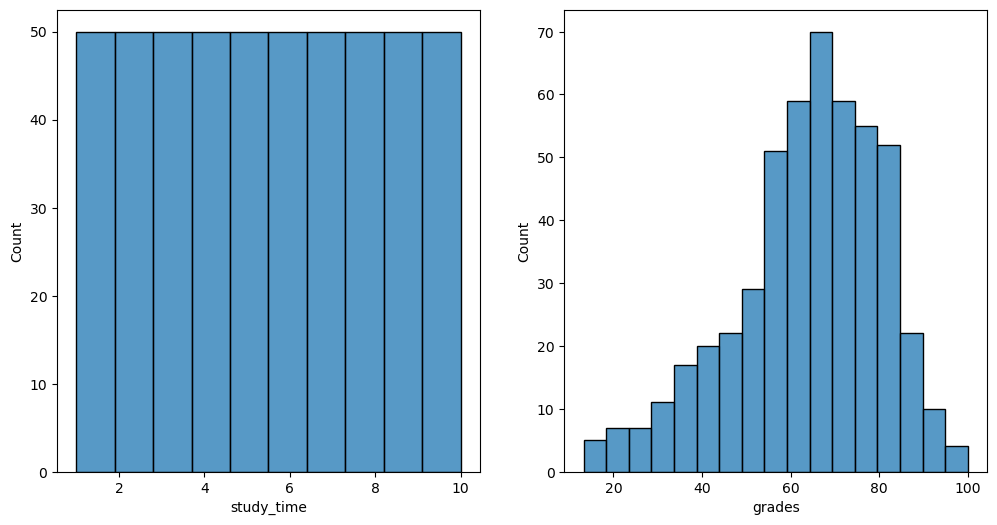

In [32]:
fig,(ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
sns.histplot(data=df['study_time'], ax=ax1)
sns.histplot(data=df['grades'],ax=ax2)

Veamos cual es el tipo de relzacion que tiene la variable `study_time` con la variable `grades`

<Axes: xlabel='study_time', ylabel='grades'>

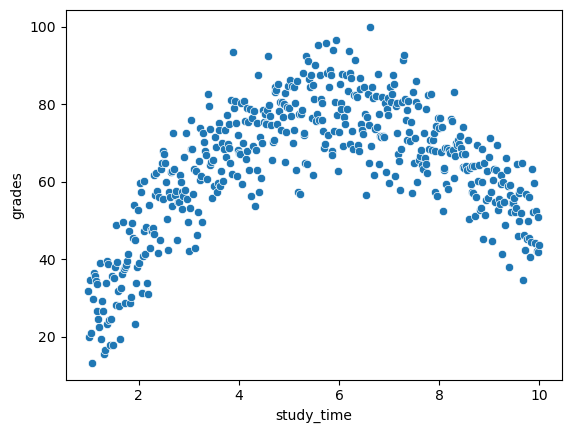

In [33]:
sns.scatterplot(x=df['study_time'], y=df['grades'])

Viendo el como se relaciona la variable `study_time` con la variable `grades`, la mejor manera de describirla podria ser con una parabola

### 2.2. (10 puntos)

Usaremos un modelo polinomial para la tarea de predicción. Elige un grado de polinomio adecuado de acuerdo a tu conclusión en el punto 2.1

Como ya se comento y se obsevo en el punto anterior creo que la mejora manera de aproximar la calificacion obtenida en funcion de la horas de estudio es con un modelo polinomial de segundo grado. Esto porque se puede observar como sigue la forma de una parabola cóncava.

### 2.3. (10 puntos)

Dividir los datos en datos de entrenamiento, y datos de prueba.

Con los datos de entrenamiento, encontrar los coeficientes de máxima verosimilitud para el polinomio.

In [40]:
# Hacemos el pipeline del modelo
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=True)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

In [41]:
# Dividimos los datos
x_train, x_test, y_train, y_test = train_test_split(df[['study_time']], df['grades'], test_size=0.2, random_state=7)

In [42]:
x_train

,study_time
342,7.168337
359,7.474950
109,2.965932
50,1.901804
452,9.152305
...,...
211,4.805611
67,2.208417
25,1.450902
196,4.535070


In [43]:
# Entrenamos el modelo para encontrar los coeficientes de MLE
model.fit(x_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures()), ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

In [44]:
# Coeficientes del modelo
model.named_steps['regressor'].coef_

array([  0.        ,  68.39366294, -63.57588541])

### 2.4. (10 puntos)

Evalúa el modelo entrenado, usando la métrica de $R^2$, tanto en el dataset de entrenamiento como en el que reservaste para pruebas.

In [ ]:
train_r = model.score(x_train, y_train)
test_r = model.score(x_test, y_test)

print(f'El score del train es: {train_r}')
print(f'El score del test es: {test_r}')

El score del train es: 0.7469282463713496
El score del test es: 0.7574123841110331
